In [392]:
## Cleaning
import pandas as pd
import re
import datetime
import ast
import math

# KMeans
from sklearn.cluster import KMeans

# Kmedoids
from sklearn_extra.cluster import KMedoids

# Global
import pickle
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator
from tabulate import tabulate
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer

# Cleaning Data

## Cleaning Nov and Des

In [397]:
def split_prov(text):
    prov = re.search(r"\((.*?)\)", text)

    if prov is not None: 
        newText = prov.group(1)
        split = newText.split()
        temp = split[-1].split('-')
        
        return temp[-1]
    return None

def split_mag(text):
    mag = re.search(r"(\d+\.\d+)\s*(Mag(?:nitudo)?)?", text)

    if mag is not None:
        return mag.group(1)
    return None

def split_depth(text):   
    depth = re.search(r"Kedlmn:(\d+)", str(text))

    if depth is not None:
        return depth.group(1)
    return None

def split_date(text):
    date = text.split()[1:3]

    if date[0] is not None:
        return date[0]
    return None

def clean_and_rename(data):
    data = data.rename(columns={
        'created_at;id_str;full_text;quote_count;reply_count;retweet_count;favorite_count;lang;user_id_str;conversation_id_str;username;tweet_url': 
        'Unnamed: 0'
    })

    index = data[data['Unnamed: 0'].str.contains('UPDATE')].index
    data.drop(index, inplace=True)
    
    return data

def make_df(data):
    df = pd.DataFrame()

    df["date"] = data[:]["Unnamed: 0"].apply(split_date)
    df["mag"] = data[:]["Unnamed: 0"].apply(split_mag)
    df["depth"] = data[:]["Unnamed: 4"].apply(split_depth)
    df["prov"] = data[:]["Unnamed: 3"].apply(split_prov)
    
    df.dropna()
    
    return df

In [398]:
nov_des = [
    pd.read_csv('./datasets/gempa_bumi_november_dirty.csv'),
    pd.read_csv('./datasets/gempa_bumi_desember_dirty.csv')
]

nov_des_df = pd.DataFrame()

for data in nov_des:
    temp = clean_and_rename(data)
    temp = make_df(temp)
    nov_des_df = pd.concat([nov_des_df, temp], ignore_index=True)

nov_des_df

,date,mag,depth,prov
0,Nov,2.5,10,MALUKU
1,Nov,3.1,10,MALUKU
2,Nov,4.7,51,PAPUA
3,Nov,3.0,26,SULUT
4,Nov,3.8,132,SULUT
...,...,...,...,...
1654,Dec,2.9,10,SULUT
1655,Dec,4.4,386,MALUKUBRTDAYA
1656,Dec,3.1,24,MALUT
1657,Dec,2.4,17,JABAR


## Cleaning Jan-April

In [402]:
def extract_quake_data(text):
    
    magnitude = re.search(r"Mag:(\d+\.\d+)", text).group(1)
    location = re.search(r"\((.+?)\)", text).group(1)
    depth = re.search(r"Kedlmn:(\d+)", text).group(1)
    prov = location.split()[-1].split('-')[-1]
    date = re.search(r"(\d{2}-\w{3}-\d{2,4})", text).group(1)

    if date:
        newDate = date.split('-')
        date = newDate[1]

    quake_data = {
        "date": date,
        "mag": magnitude,
        "depth": depth,
        "prov": prov
    }

    return quake_data

In [403]:
month_dirty = [
    pd.read_csv('./datasets/gempa_bumi_januari.csv'),
    pd.read_csv('./datasets/gempa_bumi_februari.csv'), 
    pd.read_csv('./datasets/gempa_bumi_maret.csv'),
    pd.read_csv('./datasets/gempa_bumi_april.csv')
]

month_clean = [  
]

for i in range(len(month_dirty)):
    cleaned = month_dirty[i][:]["full_text"].apply(extract_quake_data)
    month_clean.append(cleaned)

data_janap = pd.concat(month_clean)
data_janap = pd.DataFrame(data_janap.tolist())

## Gabungkan Dataset

In [404]:
data = pd.concat([nov_des_df, data_janap])
data = data.dropna()
data

,date,mag,depth,prov
0,Nov,2.5,10,MALUKU
1,Nov,3.1,10,MALUKU
2,Nov,4.7,51,PAPUA
3,Nov,3.0,26,SULUT
4,Nov,3.8,132,SULUT
...,...,...,...,...
1311,Apr,2.9,10,SULTENG
1312,Apr,3.7,10,JATIM
1313,Apr,3.0,10,SULSEL
1314,Apr,3.6,10,JATIM


## Transformasi Data

In [405]:
def encoded_loc(row, encode):
    if row['prov'] in encode:
        return encode[row['prov']]

    return None

unique_locs = data['prov'].unique()
mapLoc = {prov: i + 1 for i, prov in enumerate(unique_locs)}

data['prov_enco'] = data['prov'].map(mapLoc)
data

,date,mag,depth,prov,prov_enco
0,Nov,2.5,10,MALUKU,1
1,Nov,3.1,10,MALUKU,1
2,Nov,4.7,51,PAPUA,2
3,Nov,3.0,26,SULUT,3
4,Nov,3.8,132,SULUT,3
...,...,...,...,...,...
1311,Apr,2.9,10,SULTENG,12
1312,Apr,3.7,10,JATIM,26
1313,Apr,3.0,10,SULSEL,6
1314,Apr,3.6,10,JATIM,26


In [406]:
x = data[['mag', 'depth']]
x

,mag,depth
0,2.5,10
1,3.1,10
2,4.7,51
3,3.0,26
4,3.8,132
...,...,...
1311,2.9,10
1312,3.7,10
1313,3.0,10
1314,3.6,10


## Normalisasi Data

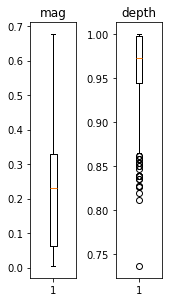

In [407]:
scaler = Normalizer()
dataScaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

plt.figure(figsize=(12, 8))
for i, column in enumerate (dataScaled.columns, 1):
    plt.subplot(2, 10, i)
    plt.boxplot(dataScaled[column])
    plt.title(column)
plt.tight_layout()
plt.show()

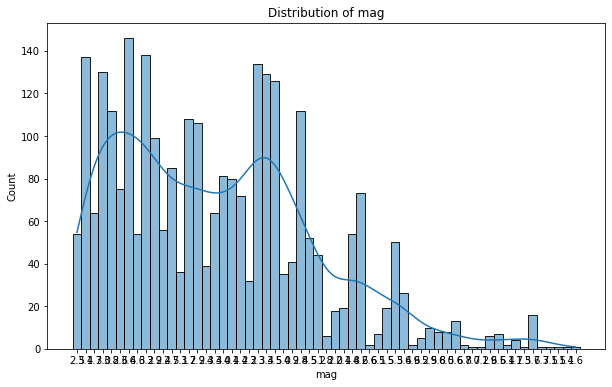

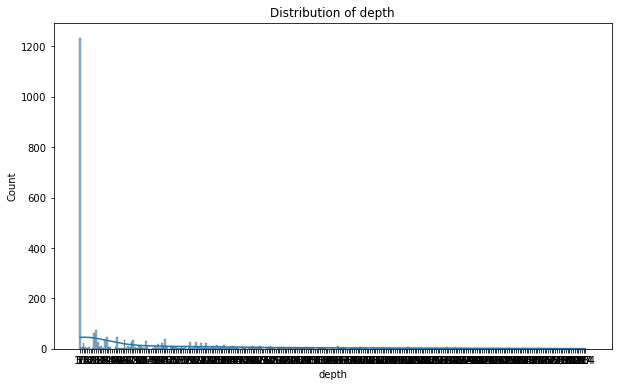

In [130]:
for column in dataScaled.columns[:6]:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

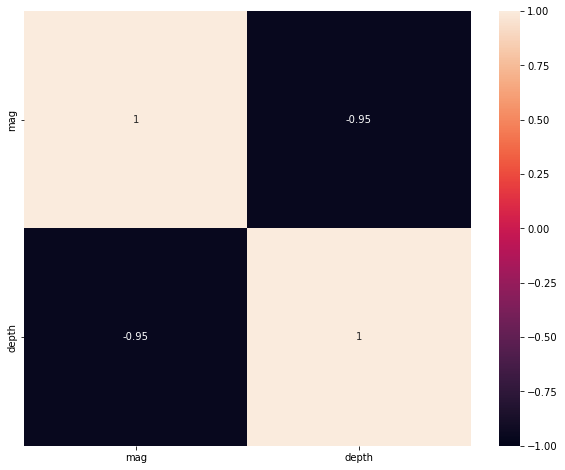

In [408]:
correlation = dataScaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1)
plt.show()

# Clustering

## K-Means

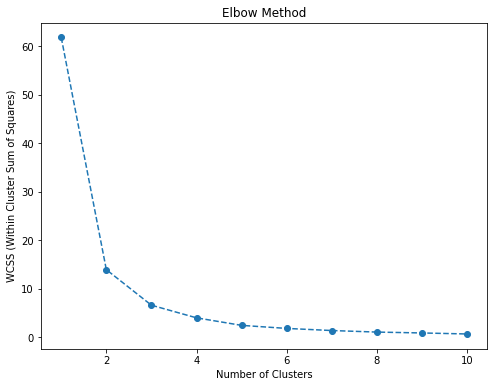

In [409]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(dataScaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [410]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

3

In [411]:
kmeans = KMeans(n_clusters=cluster_knee.elbow, random_state=42)
predict_kmeans = kmeans.fit(dataScaled)
predict_kmeans.cluster_centers_

array([[0.06312197, 0.99699988],
       [0.39406792, 0.91727897],
       [0.25956044, 0.96466809]])

In [412]:
data['kmeans'] = predict_kmeans.labels_
data['kmeans'].value_counts()

kmeans
0    1155
2     908
1     743
Name: count, dtype: int64

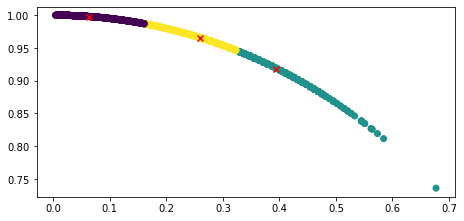

In [413]:
kmeans_data = dataScaled.to_numpy()

plt.figure(figsize=(7.5, 3.5))
plt.scatter(kmeans_data[:, 0], kmeans_data[:, 1], c=predict_kmeans.labels_, cmap='viridis')
plt.scatter(predict_kmeans.cluster_centers_[:, 0], predict_kmeans.cluster_centers_[:, 1], marker='x', color='red')
plt.show()

## K-Medoids

In [414]:
metrics = ["manhattan", "euclidean", "cosine"]
methods = ["pam", "alternate"]
locate_best_k_medoids_knee = []

for metric in metrics:
    for method in methods:
        wcss = []
        
        for i in range(2, 11): 
            kMedoids = KMedoids(metric=metric, n_clusters=i, method=method)
            predict = kMedoids.fit(dataScaled)
            wcss.append(kMedoids.inertia_)

        if len(wcss) != 10: 
            cluster_knee = KneeLocator(range(2, 11), wcss, curve='convex', direction='decreasing')
            locate_best_k_medoids_knee.append({
                'metric': metric,
                'method': method,
                'knee': cluster_knee.elbow
            })
            


/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(


In [415]:
avg_kmedoids_stack = []

for entry in locate_best_k_medoids_knee:
    metric = entry['metric']
    method = entry['method']
    knee = int(entry['knee'])

    kMedoids = KMedoids(metric=metric, n_clusters=knee, method=method)
    predict_kmedoids = kMedoids.fit_predict(dataScaled)

    if len(set(predict_kmedoids)) > 1: 
        avg_kmedoids = silhouette_score(dataScaled, predict_kmedoids)
        avg_kmedoids_stack.append({
            "metric": metric,
            "method": method,
            "knee": knee,
            "avg": avg_kmedoids
        })

/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(


In [416]:
avg_kmedoids_stack

[{'metric': 'manhattan',
  'method': 'pam',
  'knee': 5,
  'avg': 0.5895984740686483},
 {'metric': 'euclidean',
  'method': 'pam',
  'knee': 5,
  'avg': 0.5879519105631804},
 {'metric': 'cosine', 'method': 'pam', 'knee': 4, 'avg': 0.5865443224288628},
 {'metric': 'cosine',
  'method': 'alternate',
  'knee': 4,
  'avg': 0.5892679603205682}]

In [417]:
kMedoids = KMedoids(metric="manhattan", n_clusters=5, method='pam')
predict_kmedoids = kMedoids.fit(dataScaled)
kMedoids.cluster_centers_

array([[0.03281813, 0.99946134],
       [0.34700888, 0.93786184],
       [0.43273107, 0.90152306],
       [0.13621834, 0.99067884],
       [0.26835356, 0.96332049]])

In [418]:
data['kmedoids'] = predict_kmedoids.labels_
data['kmedoids'].value_counts()

kmedoids
0    811
4    649
1    552
3    466
2    328
Name: count, dtype: int64

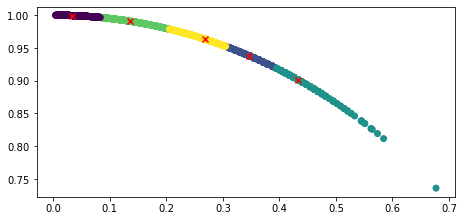

In [419]:
kmedoids_data = dataScaled.to_numpy()

plt.figure(figsize=(7.5, 3.5))
plt.scatter(kmedoids_data[:, 0], kmedoids_data[:, 1], c=predict_kmedoids.labels_, cmap='viridis')
plt.scatter(predict_kmedoids.cluster_centers_[:, 0], predict_kmedoids.cluster_centers_[:, 1], marker='x', color='red')
plt.show()

# Pengujian dan Perbandingan Silhoutte Coefficient

In [420]:
from tabulate import tabulate

avg_kmeans = silhouette_score(dataScaled, predict_kmeans.labels_)
avg_kmedoids = silhouette_score(dataScaled, predict_kmedoids.labels_)

avg = pd.DataFrame([{"K-Means": avg_kmeans, "K-Medoids": avg_kmedoids}])

print(tabulate(avg, headers='keys', tablefmt='grid', showindex=False))

+-----------+-------------+
|   K-Means |   K-Medoids |
+===========+=============+
|  0.611617 |    0.589598 |
+-----------+-------------+


## Centroid

In [421]:
labels_cluster = [0, 1, 2]
labels_data = ['mag', 'depth', 'prov_enco']
centroid_kmeans = pd.DataFrame()

for index in labels_cluster:
    for label_data in labels_data:
        if label_data == 'prov_enco':
            centroid_kmeans.at[index, label_data] = data['prov_enco'][data['kmeans'] == index].value_counts().idxmax()
            
        else:
            numpy = data[label_data][data['kmeans'] == index].to_numpy()
            numpy = numpy.astype(float)
            
            if numpy.size > 0: 
                centroid_kmeans.at[index, label_data] = numpy.mean()
            else:
                centroid_kmeans.at[index, label_data] = float('nan') 

centroid_kmeans

,mag,depth,prov_enco
0,3.637576,109.426840,3.0
1,4.312113,10.028264,3.0
2,3.198899,12.267621,12.0


# Visualisasi Data

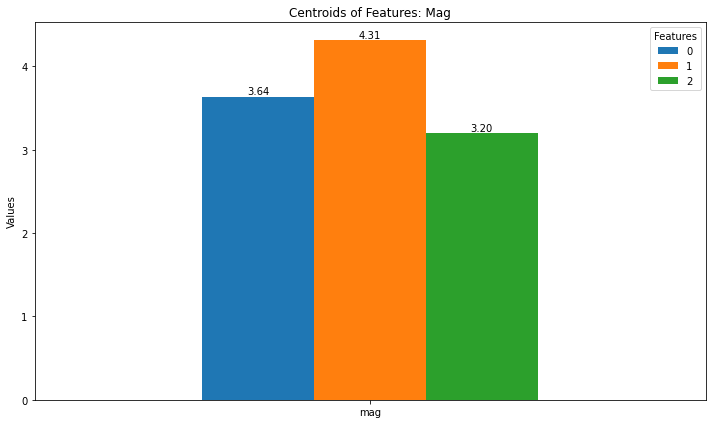

In [422]:
centroid_mag = pd.DataFrame({    
    '0': centroid_kmeans.loc[0, ['mag']],
    '1': centroid_kmeans.loc[1, ['mag']],
    '2': centroid_kmeans.loc[2, ['mag']]
})

ax = centroid_mag.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Mag')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


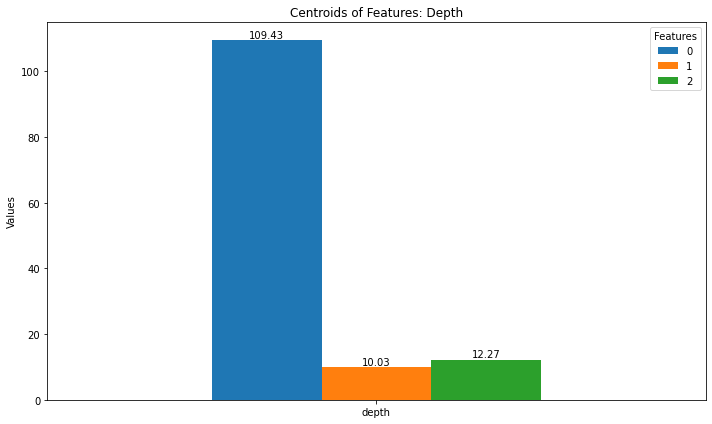

In [423]:
centroid_depth = pd.DataFrame({    
    '0': centroid_kmeans.loc[0, ['depth']],
    '1': centroid_kmeans.loc[1, ['depth']],
    '2': centroid_kmeans.loc[2, ['depth']]
})

ax = centroid_depth.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Depth')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


In [424]:
prov = []

for i in range(3):
    counts = data["prov"][data["kmeans"] == i].value_counts().head()
    for province, count in counts.items():
        prov.append({"kmeans": i, "prov": province, "count": count})

prov_plt = pd.DataFrame(prov)
prov_plt

,kmeans,prov,count
0,0,SULUT,204
1,0,NTT,175
2,0,GORONTALO,103
3,0,NTB,76
4,0,MALUT,69
5,1,SULUT,128
6,1,MALUKUTENGGARABRT,98
7,1,MALUT,57
8,1,JATIM,55
9,1,PAPUA,51


# Visual Data

In [145]:
def categorize_mag(value):
    if value <= 4:
        return 'kecil'
    elif value > 4 and value <= 6:
        return 'sedang'
    elif value > 6:
        return 'besar'

def categorize_depth(value):
    if value <= 60:
        return 'dangkal'
    elif value > 60 and value <= 300:
        return 'sedang'
    elif value > 300:
        return 'dalam'

def categorize_rad(value):
    if value <= 25:
        return 'dekat'
    elif value > 25 and value <= 100:
        return 'sedang'
    elif value > 100:
        return 'jauh'

In [146]:
def plot_visual(keys, category, text, y_lim):
    
    x = np.arange(len(keys)) 
    width = 0.25 
    multiplier = 0
    
    fig, ax = plt.subplots(layout='constrained')
    
    for attribute, measurement in category.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3) 
        multiplier += 1
    
    ax.set_ylabel('Sum')
    ax.set_title(text)
    ax.set_xticks(x + width, labels) 
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, y_lim)
    
    plt.show()

In [149]:
df = pd.DataFrame(data)

df['mag'] = df['mag'].astype(float)
df['depth'] = df['depth'].astype(float)
# df['rad'] = df['rad'].astype(float)

df['mag_category'] = df['mag'].apply(categorize_mag)
df['depth_category'] = df['depth'].apply(categorize_depth)
# df['rad_category'] = df['rad'].apply(categorize_rad)

for cluster in range(3):
    print_cluster = pd.DataFrame()
    
    print(f"Cluster {cluster}:")
    print(df[df['kmeans'] == cluster]['mag_category'].value_counts())
    print(df[df['kmeans'] == cluster]['depth_category'].value_counts())
    # print(df[df['kmeans'] == cluster]['rad_category'].value_counts(), "\n")
    cluster_df = df[df['kmeans'] == cluster][['mag', 'depth', 'prov']].head(10)
    print(tabulate(cluster_df, headers='keys', tablefmt='grid', showindex=False))
    print("\n")

Cluster 0:
mag_category
kecil     808
sedang    334
besar      13
Name: count, dtype: int64
depth_category
sedang     613
dangkal    478
dalam       64
Name: count, dtype: int64
+-------+---------+-----------+
|   mag |   depth | prov      |
+=======+=========+===========+
|   4.7 |      51 | PAPUA     |
+-------+---------+-----------+
|   3   |      26 | SULUT     |
+-------+---------+-----------+
|   3.8 |     132 | SULUT     |
+-------+---------+-----------+
|   2.6 |     188 | NTT       |
+-------+---------+-----------+
|   3.2 |      42 | SULUT     |
+-------+---------+-----------+
|   3.9 |     143 | NTT       |
+-------+---------+-----------+
|   2.6 |      81 | GORONTALO |
+-------+---------+-----------+
|   5.1 |      61 | PAPUA     |
+-------+---------+-----------+
|   2.4 |      85 | SULTENG   |
+-------+---------+-----------+
|   3.2 |      89 | SULUT     |
+-------+---------+-----------+


Cluster 1:
mag_category
sedang    411
kecil     316
besar      16
Name: count, dtype

In [109]:
df = pd.DataFrame(data)

df['mag'] = df['mag'].astype(float)
df['depth'] = df['depth'].astype(float)
df['rad'] = df['rad'].astype(float)

df['mag_category'] = df['mag'].apply(categorize_mag)
df['depth_category'] = df['depth'].apply(categorize_depth)
df['rad_category'] = df['rad'].apply(categorize_rad)

for cluster in range(4):
    print_cluster = pd.DataFrame()
    
    print(f"Cluster {cluster}:")
    print(df[df['kmedoids'] == cluster]['mag_category'].value_counts())
    print(df[df['kmedoids'] == cluster]['depth_category'].value_counts())
    print(df[df['kmedoids'] == cluster]['rad_category'].value_counts(), "\n")
    cluster_df = df[df['kmedoids'] == cluster][['mag', 'depth', 'rad', 'prov', 'lat', 'lon']].head(10)
    print(tabulate(cluster_df, headers='keys', tablefmt='grid', showindex=False))
    print("\n")

Cluster 0:
mag_category
kecil     496
sedang    315
besar      15
Name: count, dtype: int64
depth_category
dangkal    768
sedang      57
dalam        1
Name: count, dtype: int64
rad_category
jauh      451
sedang    375
Name: count, dtype: int64 

+-------+---------+-------+-----------+--------+--------+
|   mag |   depth |   rad | prov      |    lat |    lon |
+=======+=========+=======+===========+========+========+
|   3.6 |      10 |    74 | PAPUABRT  |  -3.92 | 133.71 |
+-------+---------+-------+-----------+--------+--------+
|   3.2 |      10 |   116 | JABAR     |  -8.5  | 107.82 |
+-------+---------+-------+-----------+--------+--------+
|   5   |      11 |   129 | MALUT     |   1.96 | 126.6  |
+-------+---------+-------+-----------+--------+--------+
|   3.7 |      11 |    80 | PAPUA     |  -2.14 | 139.85 |
+-------+---------+-------+-----------+--------+--------+
|   3.2 |      10 |    49 | SULTENG   |  -1.61 | 120.36 |
+-------+---------+-------+-----------+--------+--------+

## Visualisasi data gempa bumi

In [154]:
unique_keys = np.sort(df['kmeans'].unique())
np.array(['mag', 'depth'])

mag = []
depth = []

for i in range(4):
    kecil_count = df[(df['kmeans'] == i) & (df['mag_category'] == "kecil")]['mag_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['mag_category'] == "sedang")]['mag_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['mag_category'] == "besar")]['mag_category'].value_counts()
    
    mag.append(kecil_count.get("kecil", 0))
    depth.append(sedang_count.get("sedang", 0))
    besar.append(besar_count.get("besar", 0))

labels = np.array(['mag', 'depth'])
cluster = {
    'mag': (mag),
    'depth': (depth),
}

cluster

# plot_visual(labels, category, "Magnitude", 750)

{'Kecil': [808,
  316,
  832,
  0,
  808,
  316,
  832,
  0,
  808,
  316,
  832,
  0,
  808,
  316,
  832,
  0,
  808,
  316,
  832,
  0],
 'Sedang': [334,
  411,
  74,
  0,
  334,
  411,
  74,
  0,
  334,
  411,
  74,
  0,
  334,
  411,
  74,
  0,
  334,
  411,
  74,
  0],
 'Besar': [13,
  16,
  2,
  0,
  13,
  16,
  2,
  0,
  13,
  16,
  2,
  0,
  13,
  16,
  2,
  0,
  13,
  16,
  2,
  0]}

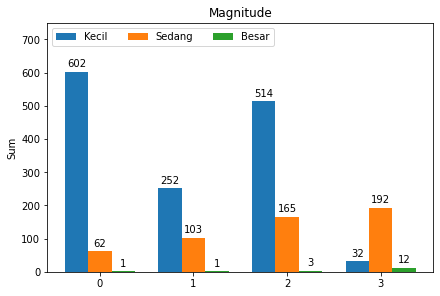

In [134]:
unique_keys = np.sort(df['kmedoids'].unique())
np.array(unique_keys)

kecil = []
sedang = []
besar = []

for i in range(4):
    kecil_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "kecil")]['mag_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "sedang")]['mag_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "besar")]['mag_category'].value_counts()
    
    kecil.append(kecil_count.get("kecil", 0))
    sedang.append(sedang_count.get("sedang", 0))
    besar.append(besar_count.get("besar", 0))

labels = np.array(unique_keys)
category = {
    'Kecil': (kecil),
    'Sedang': (sedang),
    'Besar': (besar),
}

plot_visual(labels, category, "Magnitude", 750)

## Visualisasi kedalaman

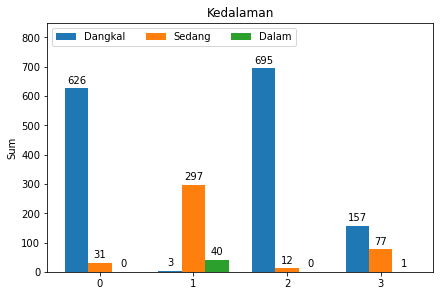

In [135]:
unique_keys = np.sort(df['kmeans'].unique())
np.array(unique_keys)

dangkal = []
sedang = []
dalam = []

for i in range(4):
    kecil_count = df[(df['kmeans'] == i) & (df['depth_category'] == "dangkal")]['depth_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['depth_category'] == "sedang")]['depth_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['depth_category'] == "dalam")]['depth_category'].value_counts()
    
    dangkal.append(kecil_count.get("dangkal", 0))
    sedang.append(sedang_count.get("sedang", 0))
    dalam.append(besar_count.get("dalam", 0))

labels = np.array(unique_keys)
category = {
    'Dangkal': (dangkal),
    'Sedang': (sedang),
    'Dalam': (dalam),
}

plot_visual(labels, category, "Kedalaman", 850)

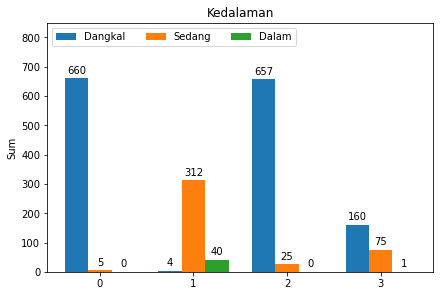

In [136]:
unique_keys = np.sort(df['kmedoids'].unique())
np.array(unique_keys)

dangkal = []
sedang = []
dalam = []

for i in range(4):
    kecil_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "dangkal")]['depth_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "sedang")]['depth_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "dalam")]['depth_category'].value_counts()
    
    dangkal.append(kecil_count.get("dangkal", 0))
    sedang.append(sedang_count.get("sedang", 0))
    dalam.append(besar_count.get("dalam", 0))

labels = np.array(unique_keys)
category = {
    'Dangkal': (dangkal),
    'Sedang': (sedang),
    'Dalam': (dalam),
}

plot_visual(labels, category, "Kedalaman", 850)

## Visualisasi Jarak

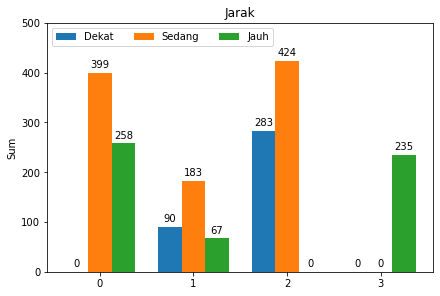

In [137]:
unique_keys = np.sort(df['kmeans'].unique())
np.array(unique_keys)

dekat = []
sedang = []
jauh = []

for i in range(4):
    kecil_count = df[(df['kmeans'] == i) & (df['rad_category'] == "dekat")]['rad_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['rad_category'] == "sedang")]['rad_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['rad_category'] == "jauh")]['rad_category'].value_counts()
    
    dekat.append(kecil_count.get("dekat", 0))
    sedang.append(sedang_count.get("sedang", 0))
    jauh.append(besar_count.get("jauh", 0))

labels = np.array(unique_keys)
category = {
    'Dekat': (dekat),
    'Sedang': (sedang),
    'Jauh': (jauh),
}

plot_visual(labels, category, "Jarak", 500)

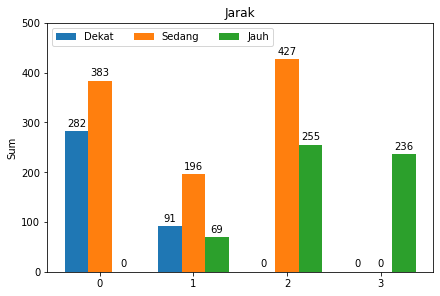

In [138]:
unique_keys = np.sort(df['kmedoids'].unique())
np.array(unique_keys)

dekat = []
sedang = []
jauh = []

for i in range(4):
    kecil_count = df[(df['kmedoids'] == i) & (df['rad_category'] == "dekat")]['rad_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['rad_category'] == "sedang")]['rad_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['rad_category'] == "jauh")]['rad_category'].value_counts()
    
    dekat.append(kecil_count.get("dekat", 0))
    sedang.append(sedang_count.get("sedang", 0))
    jauh.append(besar_count.get("jauh", 0))

labels = np.array(unique_keys)
category = {
    'Dekat': (dekat),
    'Sedang': (sedang),
    'Jauh': (jauh),
}

plot_visual(labels, category, "Jarak", 500)

## Export Model

In [201]:
cluster_input = pd.DataFrame({
    'mag': [1.4],
    'depth': [10],
    'prov': ['SULTENG']
})

cluster_input

,mag,depth,prov
0,1.4,10,SULTENG


In [202]:
x = cluster_input[['mag', 'depth']]

predict = kmeans.predict(x)
predict

array([0], dtype=int32)

In [198]:
data.to_csv('dataset.csv', index=False)

In [195]:
## KMeans Model
with open('kmeans_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)
    
print("Model saved to kmeans_model.pkl")

Model saved to kmeans_model.pkl


In [196]:
with open('kmedoids_model.pkl', 'wb') as file:
    pickle.dump(kMedoids, file)
    
print("Model saved to kmedoids_model.pkl")

Model saved to kmedoids_model.pkl
